# 🚢 Titanic EDA - Exploratory Data Analysis

## 📋 Mục Tiêu
Thực hiện phân tích khám phá dữ liệu (EDA) đầy đủ và triệt để cho dataset Titanic để:
- Hiểu rõ cấu trúc và đặc điểm của dữ liệu
- Phát hiện patterns, xu hướng và mối quan hệ
- Xác định các yếu tố ảnh hưởng đến khả năng sống sót
- Chuẩn bị dữ liệu cho việc xây dựng mô hình Machine Learning

## 🎯 Phương Pháp
- **Statistical Analysis**: Thống kê mô tả, correlation analysis
- **Visualization**: Charts, plots, heatmaps
- **Feature Engineering**: Tạo features mới từ dữ liệu gốc
- **Cross-feature Analysis**: Phân tích mối quan hệ giữa các features

---


## 📚 1. Import Thư Viện Cần Thiết


In [1]:
# Import thư viện cơ bản
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho plots
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Đã import thư viện thành công")
print("📊 Sẵn sàng cho việc khảo sát dữ liệu")


✅ Đã import thư viện thành công
📊 Sẵn sàng cho việc khảo sát dữ liệu


## 📊 2. Tải Và Gộp Dữ Liệu


In [2]:
# Tải dữ liệu
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("📊 Thông tin cơ bản về datasets:")
print(f"Train dataset: {train_df.shape}")
print(f"Test dataset: {test_df.shape}")
print(f"Tổng cộng: {train_df.shape[0] + test_df.shape[0]} hành khách")

print("\n📋 Các cột trong dataset:")
print(f"Train columns: {list(train_df.columns)}")
print(f"Test columns: {list(test_df.columns)}")

# Gộp dữ liệu để EDA toàn diện
full_df = pd.concat([train_df, test_df], ignore_index=True)
print(f"\n🔗 Dataset gộp: {full_df.shape}")
print(f"Missing values trong dataset gộp: {full_df.isnull().sum().sum()}")


📊 Thông tin cơ bản về datasets:
Train dataset: (891, 12)
Test dataset: (418, 11)
Tổng cộng: 1309 hành khách

📋 Các cột trong dataset:
Train columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Test columns: ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

🔗 Dataset gộp: (1309, 12)
Missing values trong dataset gộp: 1698


## 🔍 3. Khám Phá Cấu Trúc Dữ Liệu


## 🔧 3.1. Tạo Features Cần Thiết Cho EDA


In [ ]:
# Tạo tất cả features cần thiết cho full_df để sử dụng trong EDA
print("🔧 TẠO FEATURES CẦN THIẾT CHO EDA")
print("="*40)

# 1. Title từ Name
full_df['Title'] = full_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
full_df['Title'] = full_df['Title'].replace(['Lady', 'Countess','Capt', 'Col',
'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
full_df['Title'] = full_df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})

# 2. Deck từ Cabin
full_df['Deck'] = full_df['Cabin'].str[0].fillna('U')

# 3. Family features
full_df['FamilySize'] = full_df['SibSp'] + full_df['Parch'] + 1
full_df['IsAlone'] = (full_df['FamilySize'] == 1).astype(int)

# 4. Age và Fare groups
full_df['AgeGroup'] = pd.cut(full_df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                             labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'])
full_df['FareGroup'] = pd.cut(full_df['Fare'], bins=[0, 7.91, 14.45, 31, 1000], 
                              labels=['Low', 'Medium', 'High', 'Very High'])

print("✅ Đã tạo tất cả features cần thiết:")
print("- Title: Từ Name")
print("- Deck: Từ Cabin") 
print("- FamilySize, IsAlone: Từ SibSp, Parch")
print("- AgeGroup, FareGroup: Từ Age, Fare")
print(f"\n📊 Full dataset shape: {full_df.shape}")
print(f"📋 Features mới: {['Title', 'Deck', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup']}")


In [3]:
# Hiển thị thông tin chi tiết về dataset
print("🔍 THÔNG TIN CHI TIẾT VỀ DATASET")
print("="*50)

print("\n📊 Thông tin tổng quan:")
print(full_df.info())

print("\n📈 Thống kê mô tả cho numerical features:")
print(full_df.describe())

print("\n📋 Thống kê mô tả cho categorical features:")
print(full_df.describe(include=['object']))

print("\n❌ Missing values chi tiết:")
missing_data = full_df.isnull().sum()
missing_percent = (missing_data / len(full_df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
}).sort_values('Missing Count', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])


🔍 THÔNG TIN CHI TIẾT VỀ DATASET

📊 Thông tin tổng quan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB
None

📈 Thống kê mô tả cho numerical features:
       PassengerId    Survived       Pclass          Age        SibSp  \
count  1309.000000  891.000000  1309.000000  1046.000000  1309.00

## 🎯 4. Phân Tích Target Variable (Survived)


🎯 PHÂN TÍCH TARGET VARIABLE (SURVIVED)

📊 Thống kê survival:
Số người không sống sót: 549 (61.6%)
Số người sống sót: 342 (38.4%)
Tổng số hành khách: 891


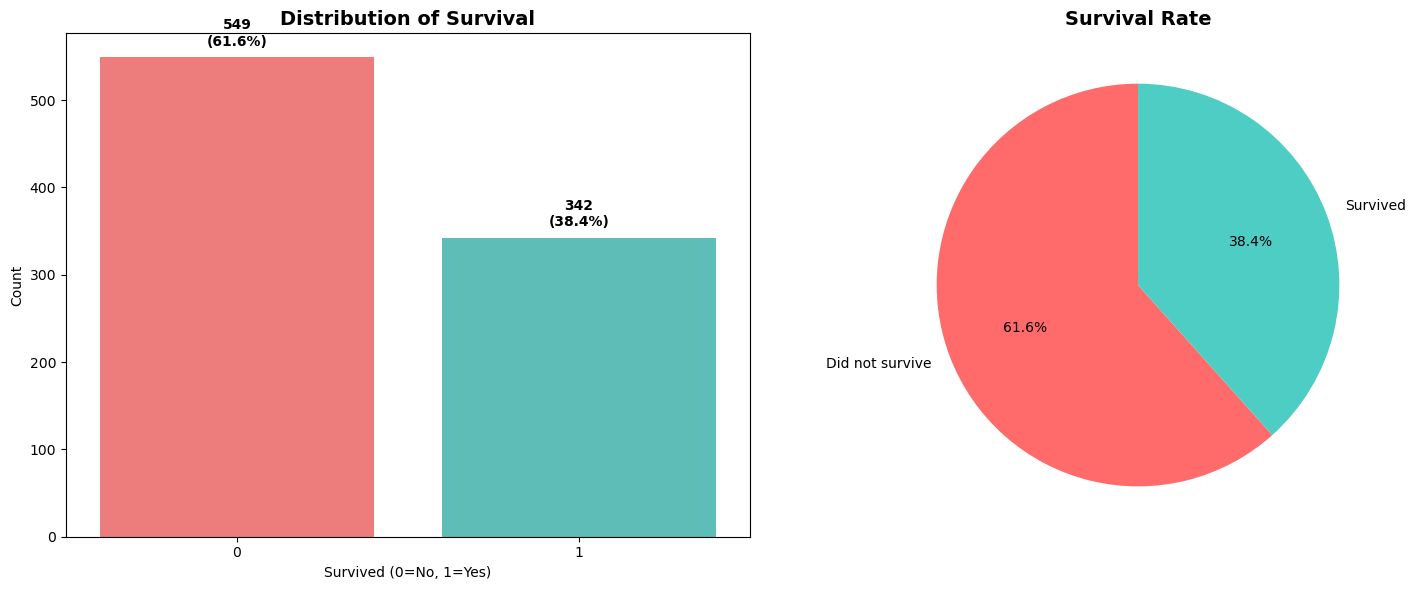


💡 Insight: Tỷ lệ sống sót tổng thể là 38.4%
Đây là một bài toán classification với class imbalance nhẹ


In [4]:
# Phân tích target variable (chỉ có trong train set)
print("🎯 PHÂN TÍCH TARGET VARIABLE (SURVIVED)")
print("="*50)

survival_stats = train_df['Survived'].value_counts()
survival_percent = train_df['Survived'].value_counts(normalize=True) * 100

print(f"\n📊 Thống kê survival:")
print(f"Số người không sống sót: {survival_stats[0]} ({survival_percent[0]:.1f}%)")
print(f"Số người sống sót: {survival_stats[1]} ({survival_percent[1]:.1f}%)")
print(f"Tổng số hành khách: {len(train_df)}")

# Visualize survival distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Count plot
sns.countplot(data=train_df, x='Survived', ax=ax1, palette=['#ff6b6b', '#4ecdc4'])
ax1.set_title('Distribution of Survival', fontsize=14, fontweight='bold')
ax1.set_xlabel('Survived (0=No, 1=Yes)')
ax1.set_ylabel('Count')
for i, v in enumerate(survival_stats):
    ax1.text(i, v + 10, f'{v}\n({survival_percent[i]:.1f}%)', 
             ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = ['#ff6b6b', '#4ecdc4']
labels = ['Did not survive', 'Survived']
ax2.pie(survival_stats, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Survival Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Insight: Tỷ lệ sống sót tổng thể là {survival_percent[1]:.1f}%")
print("Đây là một bài toán classification với class imbalance nhẹ")


## 📊 5. Phân Tích Các Features Categorical


📊 PHÂN TÍCH CÁC FEATURES CATEGORICAL

🔍 Pclass:
Pclass
3    709
1    323
2    277
Name: count, dtype: int64

🔍 Sex:
Sex
male      843
female    466
Name: count, dtype: int64

🔍 Embarked:
Embarked
S    914
C    270
Q    123
Name: count, dtype: int64

🔍 SibSp:
SibSp
0    891
1    319
2     42
4     22
3     20
8      9
5      6
Name: count, dtype: int64

🔍 Parch:
Parch
0    1002
1     170
2     113
3       8
5       6
4       6
6       2
9       2
Name: count, dtype: int64


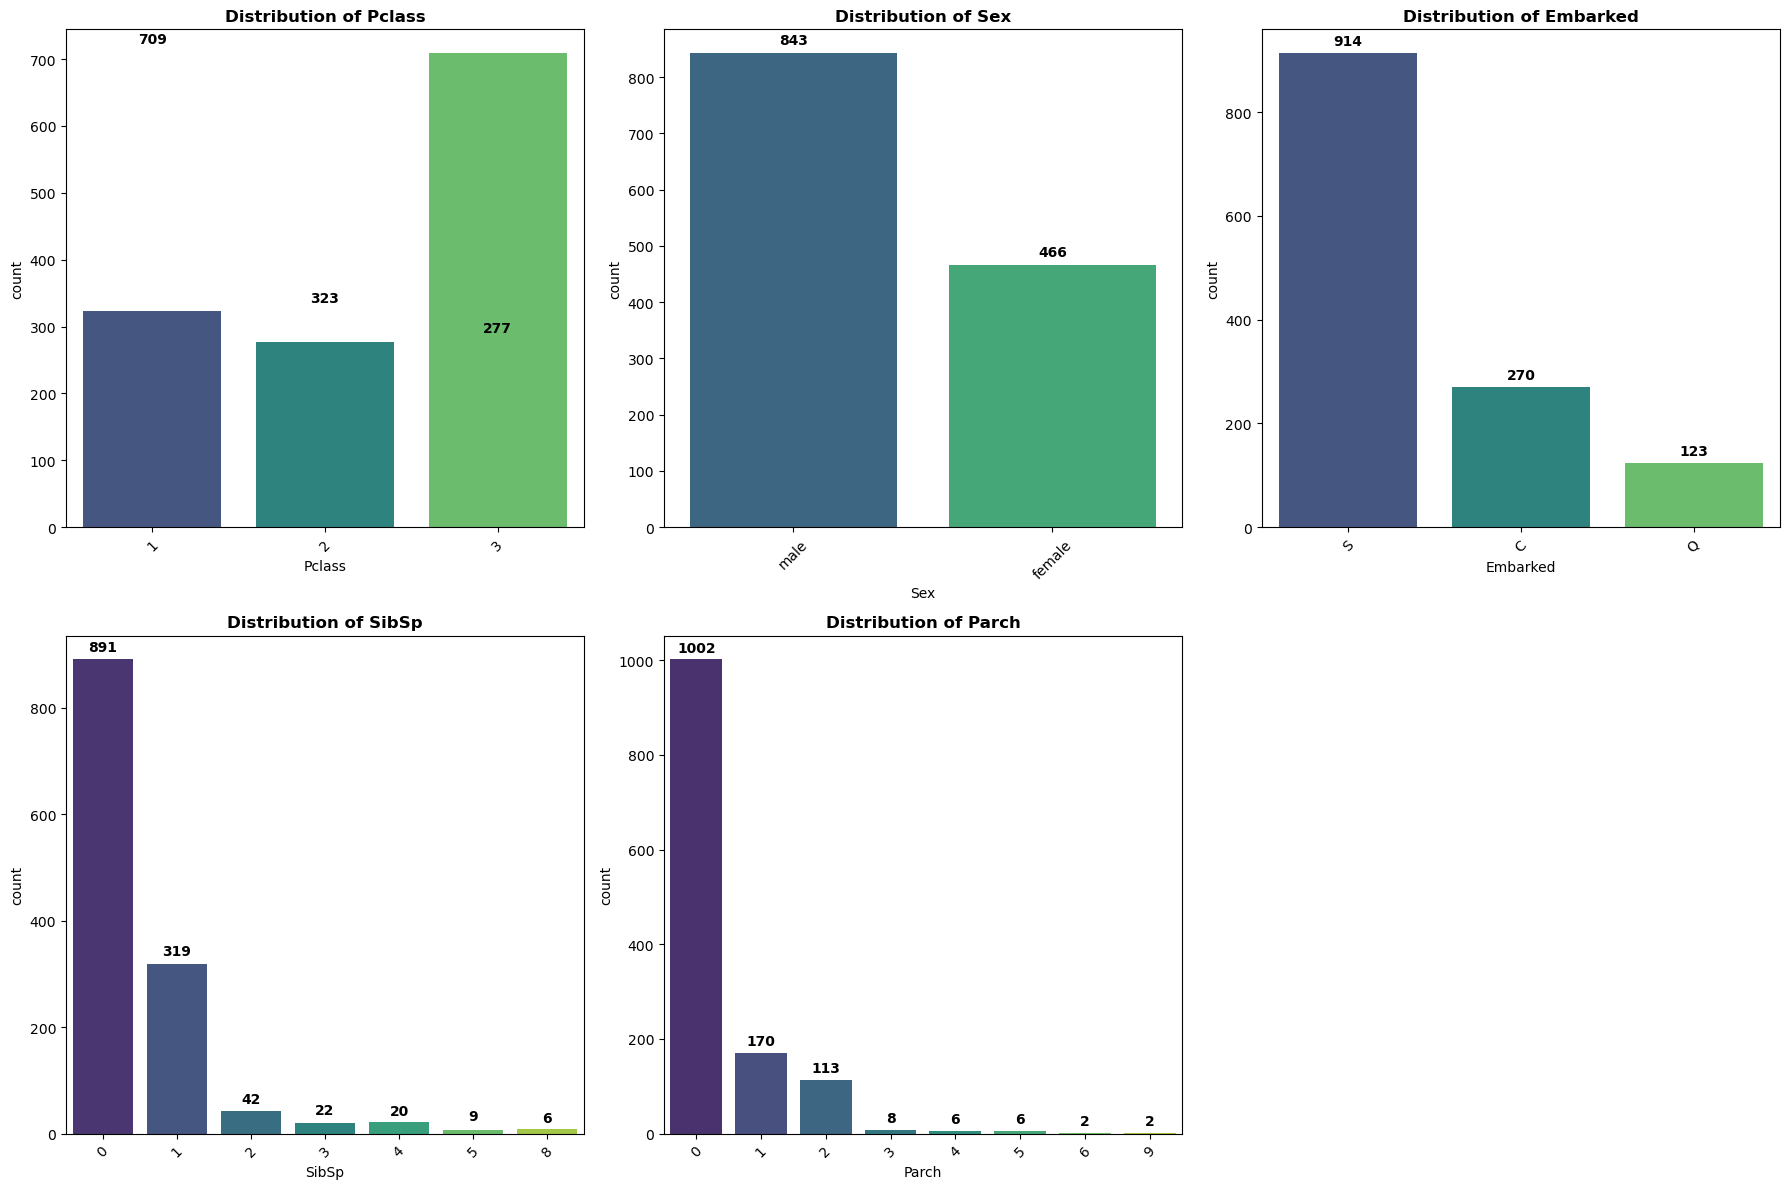


📋 Unique values trong mỗi categorical feature:
Pclass: 3 unique values
Sex: 2 unique values
Embarked: 3 unique values
SibSp: 7 unique values
Parch: 8 unique values


In [5]:
# Phân tích các features categorical
print("📊 PHÂN TÍCH CÁC FEATURES CATEGORICAL")
print("="*50)

categorical_features = ['Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(categorical_features):
    # Thống kê
    value_counts = full_df[feature].value_counts()
    print(f"\n🔍 {feature}:")
    print(value_counts)
    
    # Visualization
    if i < len(axes):
        sns.countplot(data=full_df, x=feature, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribution of {feature}', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Thêm số liệu lên bars
        for j, v in enumerate(value_counts):
            axes[i].text(j, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

# Ẩn subplot thừa
if len(categorical_features) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

# Phân tích unique values
print(f"\n📋 Unique values trong mỗi categorical feature:")
for feature in categorical_features:
    unique_count = full_df[feature].nunique()
    print(f"{feature}: {unique_count} unique values")


## 📈 6. Phân Tích Các Features Numerical


📈 PHÂN TÍCH CÁC FEATURES NUMERICAL


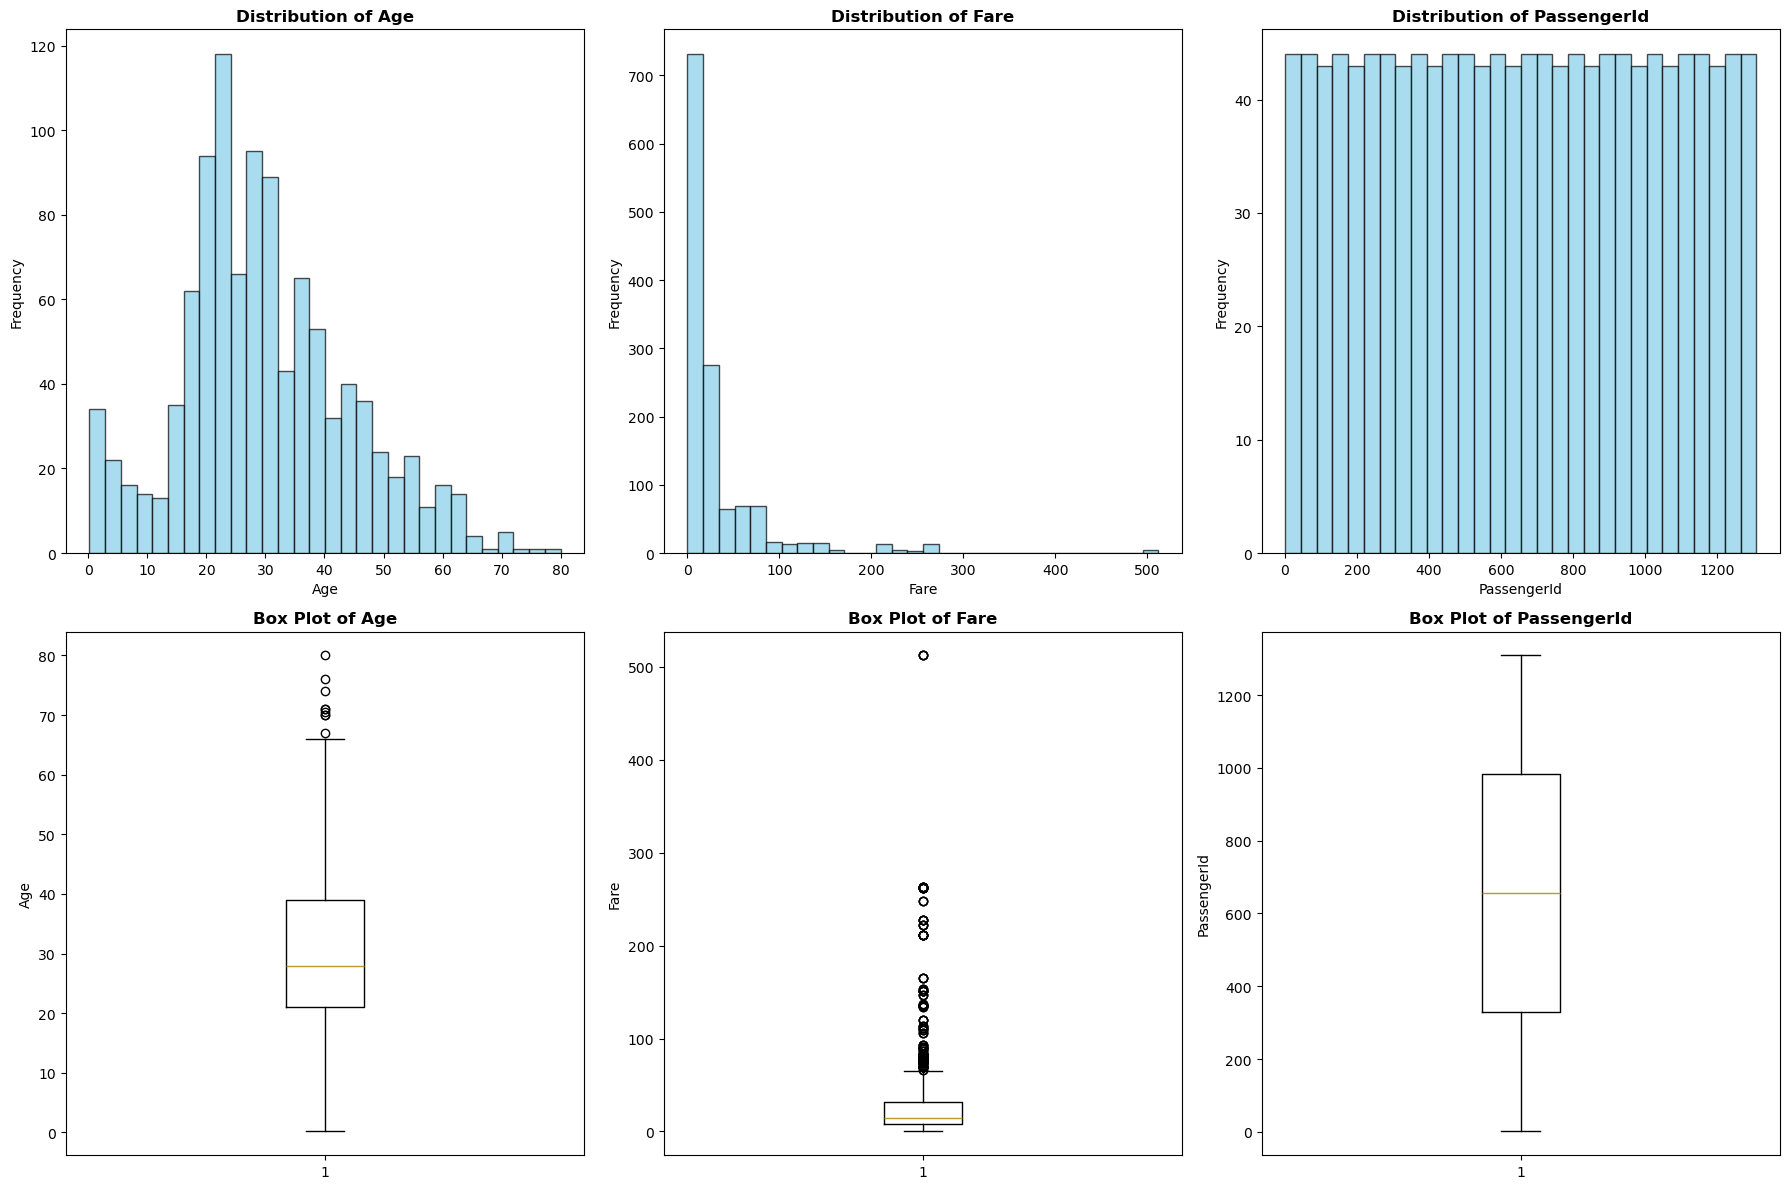


📊 Thống kê chi tiết cho numerical features:

🔍 Age:
Mean: 29.88
Median: 28.00
Std: 14.41
Min: 0.17
Max: 80.00
Missing values: 263

🔍 Fare:
Mean: 33.30
Median: 14.45
Std: 51.76
Min: 0.00
Max: 512.33
Missing values: 1

🔍 PassengerId:
Mean: 655.00
Median: 655.00
Std: 378.02
Min: 1.00
Max: 1309.00
Missing values: 0

🚨 Outliers Analysis:
Age: 9 outliers (0.7%)
Fare: 171 outliers (13.1%)


In [6]:
# Phân tích các features numerical
print("📈 PHÂN TÍCH CÁC FEATURES NUMERICAL")
print("="*50)

numerical_features = ['Age', 'Fare', 'PassengerId']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Histograms
for i, feature in enumerate(numerical_features):
    if i < 3:
        # Histogram
        axes[0, i].hist(full_df[feature].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0, i].set_title(f'Distribution of {feature}', fontweight='bold')
        axes[0, i].set_xlabel(feature)
        axes[0, i].set_ylabel('Frequency')
        
        # Box plot
        axes[1, i].boxplot(full_df[feature].dropna())
        axes[1, i].set_title(f'Box Plot of {feature}', fontweight='bold')
        axes[1, i].set_ylabel(feature)

plt.tight_layout()
plt.show()

# Thống kê chi tiết
print("\n📊 Thống kê chi tiết cho numerical features:")
for feature in numerical_features:
    print(f"\n🔍 {feature}:")
    stats = full_df[feature].describe()
    print(f"Mean: {stats['mean']:.2f}")
    print(f"Median: {stats['50%']:.2f}")
    print(f"Std: {stats['std']:.2f}")
    print(f"Min: {stats['min']:.2f}")
    print(f"Max: {stats['max']:.2f}")
    print(f"Missing values: {full_df[feature].isnull().sum()}")

# Phân tích outliers
print(f"\n🚨 Outliers Analysis:")
for feature in ['Age', 'Fare']:
    Q1 = full_df[feature].quantile(0.25)
    Q3 = full_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = full_df[(full_df[feature] < lower_bound) | (full_df[feature] > upper_bound)]
    print(f"{feature}: {len(outliers)} outliers ({len(outliers)/len(full_df)*100:.1f}%)")


## 🔗 7. Phân Tích Mối Quan Hệ Giữa Features và Survival


🔗 PHÂN TÍCH MỐI QUAN HỆ GIỮA FEATURES VÀ SURVIVAL

📊 Pclass vs Survival:
   Pclass  Total  Survived  Survival_Rate
0       1    216       136       0.629630
1       2    184        87       0.472826
2       3    491       119       0.242363

📊 Sex vs Survival:
      Sex  Total  Survived  Survival_Rate
0  female    314       233       0.742038
1    male    577       109       0.188908

📊 Embarked vs Survival:
  Embarked  Total  Survived  Survival_Rate
0        C    168        93       0.553571
1        Q     77        30       0.389610
2        S    644       217       0.336957

📊 SibSp vs Survival:
   SibSp  Total  Survived  Survival_Rate
0      0    608       210       0.345395
1      1    209       112       0.535885
2      2     28        13       0.464286
3      3     16         4       0.250000
4      4     18         3       0.166667
5      5      5         0       0.000000
6      8      7         0       0.000000

📊 Parch vs Survival:
   Parch  Total  Survived  Survival_Rate
0  

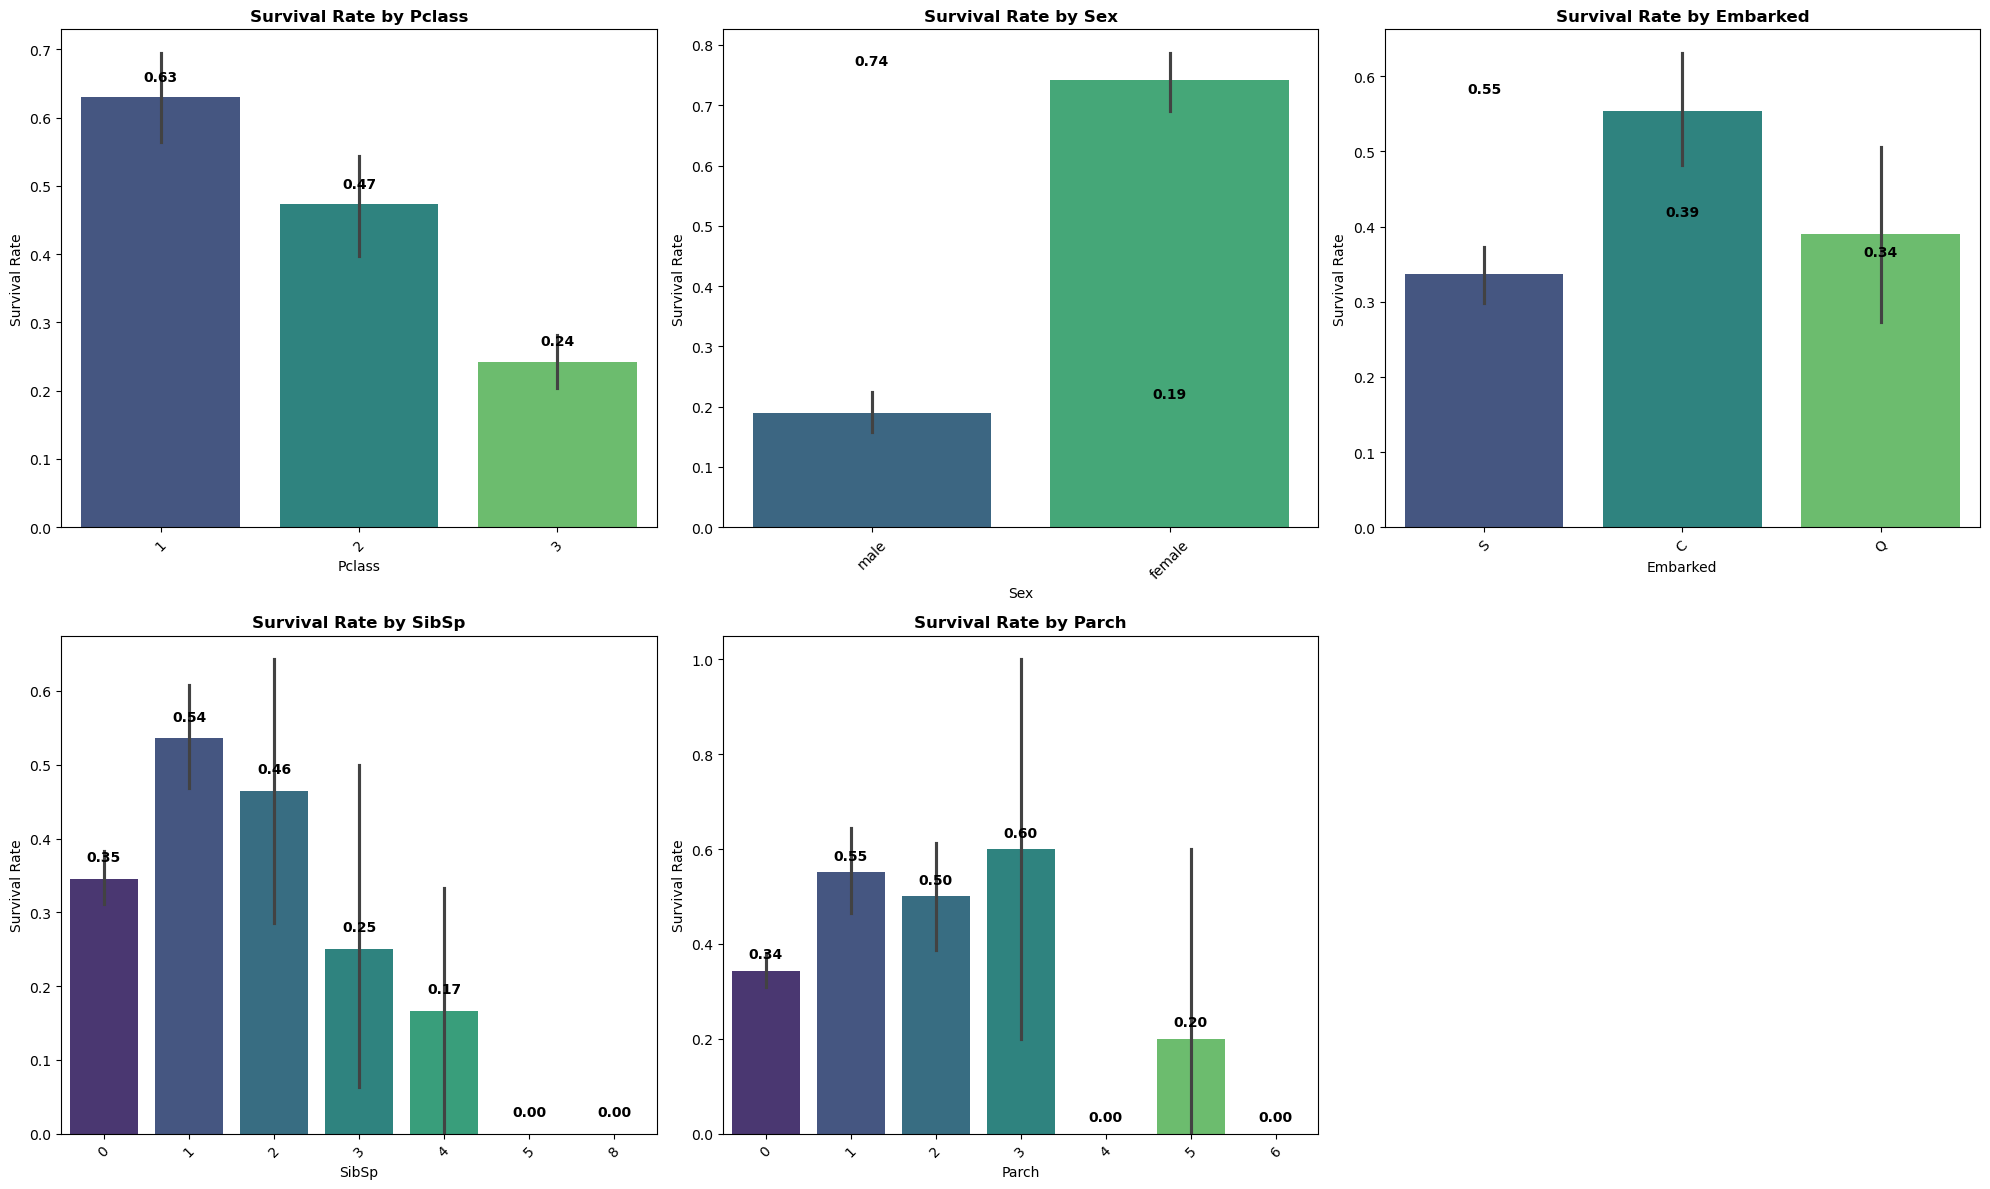


🔍 CORRELATION ANALYSIS:


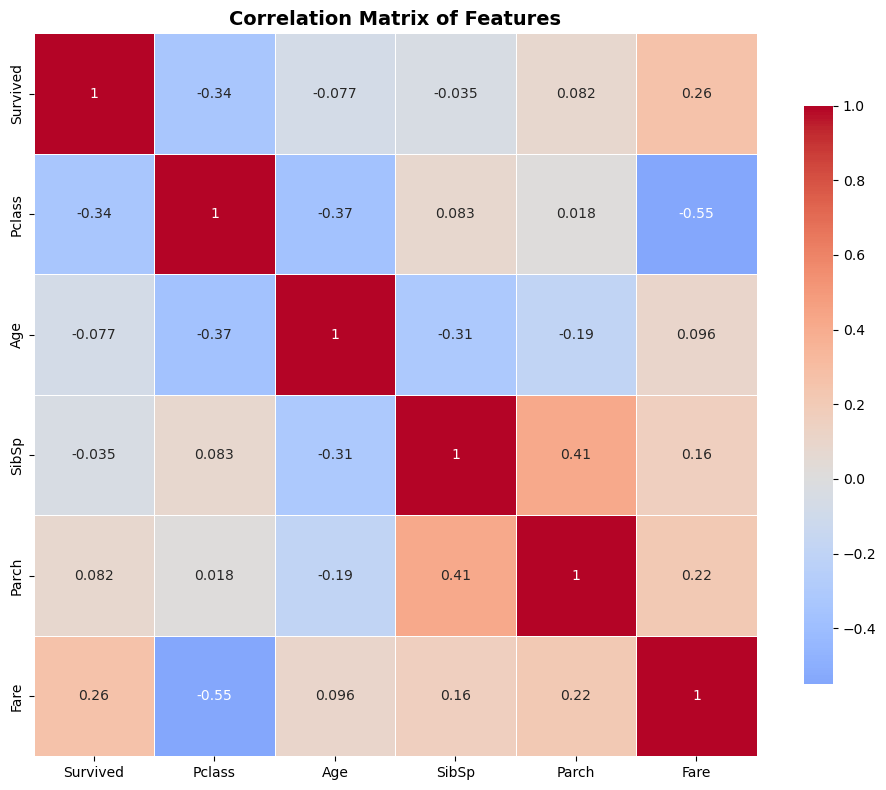


📈 Correlation với Survival (từ cao đến thấp):
Pclass: -0.338
Fare: 0.257
Parch: 0.082
Age: -0.077
SibSp: -0.035


In [7]:
# Phân tích mối quan hệ giữa features và survival
print("🔗 PHÂN TÍCH MỐI QUAN HỆ GIỮA FEATURES VÀ SURVIVAL")
print("="*60)

# 1. Survival rate theo từng feature
categorical_features = ['Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, feature in enumerate(categorical_features):
    if i < len(axes):
        # Tính survival rate
        survival_rate = train_df.groupby(feature)['Survived'].agg(['count', 'sum', 'mean']).reset_index()
        survival_rate.columns = [feature, 'Total', 'Survived', 'Survival_Rate']
        
        print(f"\n📊 {feature} vs Survival:")
        print(survival_rate)
        
        # Visualization
        sns.barplot(data=train_df, x=feature, y='Survived', ax=axes[i], palette='viridis')
        axes[i].set_title(f'Survival Rate by {feature}', fontweight='bold')
        axes[i].set_ylabel('Survival Rate')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Thêm survival rate lên bars
        for j, rate in enumerate(survival_rate['Survival_Rate']):
            axes[i].text(j, rate + 0.02, f'{rate:.2f}', ha='center', va='bottom', fontweight='bold')

# Ẩn subplot thừa
if len(categorical_features) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

# 2. Correlation matrix
print(f"\n🔍 CORRELATION ANALYSIS:")
correlation_features = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
correlation_matrix = train_df[correlation_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📈 Correlation với Survival (từ cao đến thấp):")
survival_corr = correlation_matrix['Survived'].drop('Survived').sort_values(key=abs, ascending=False)
for feature, corr in survival_corr.items():
    print(f"{feature}: {corr:.3f}")


## 📊 8. Phân Tích Chi Tiết Age và Fare


📊 PHÂN TÍCH CHI TIẾT AGE VÀ FARE


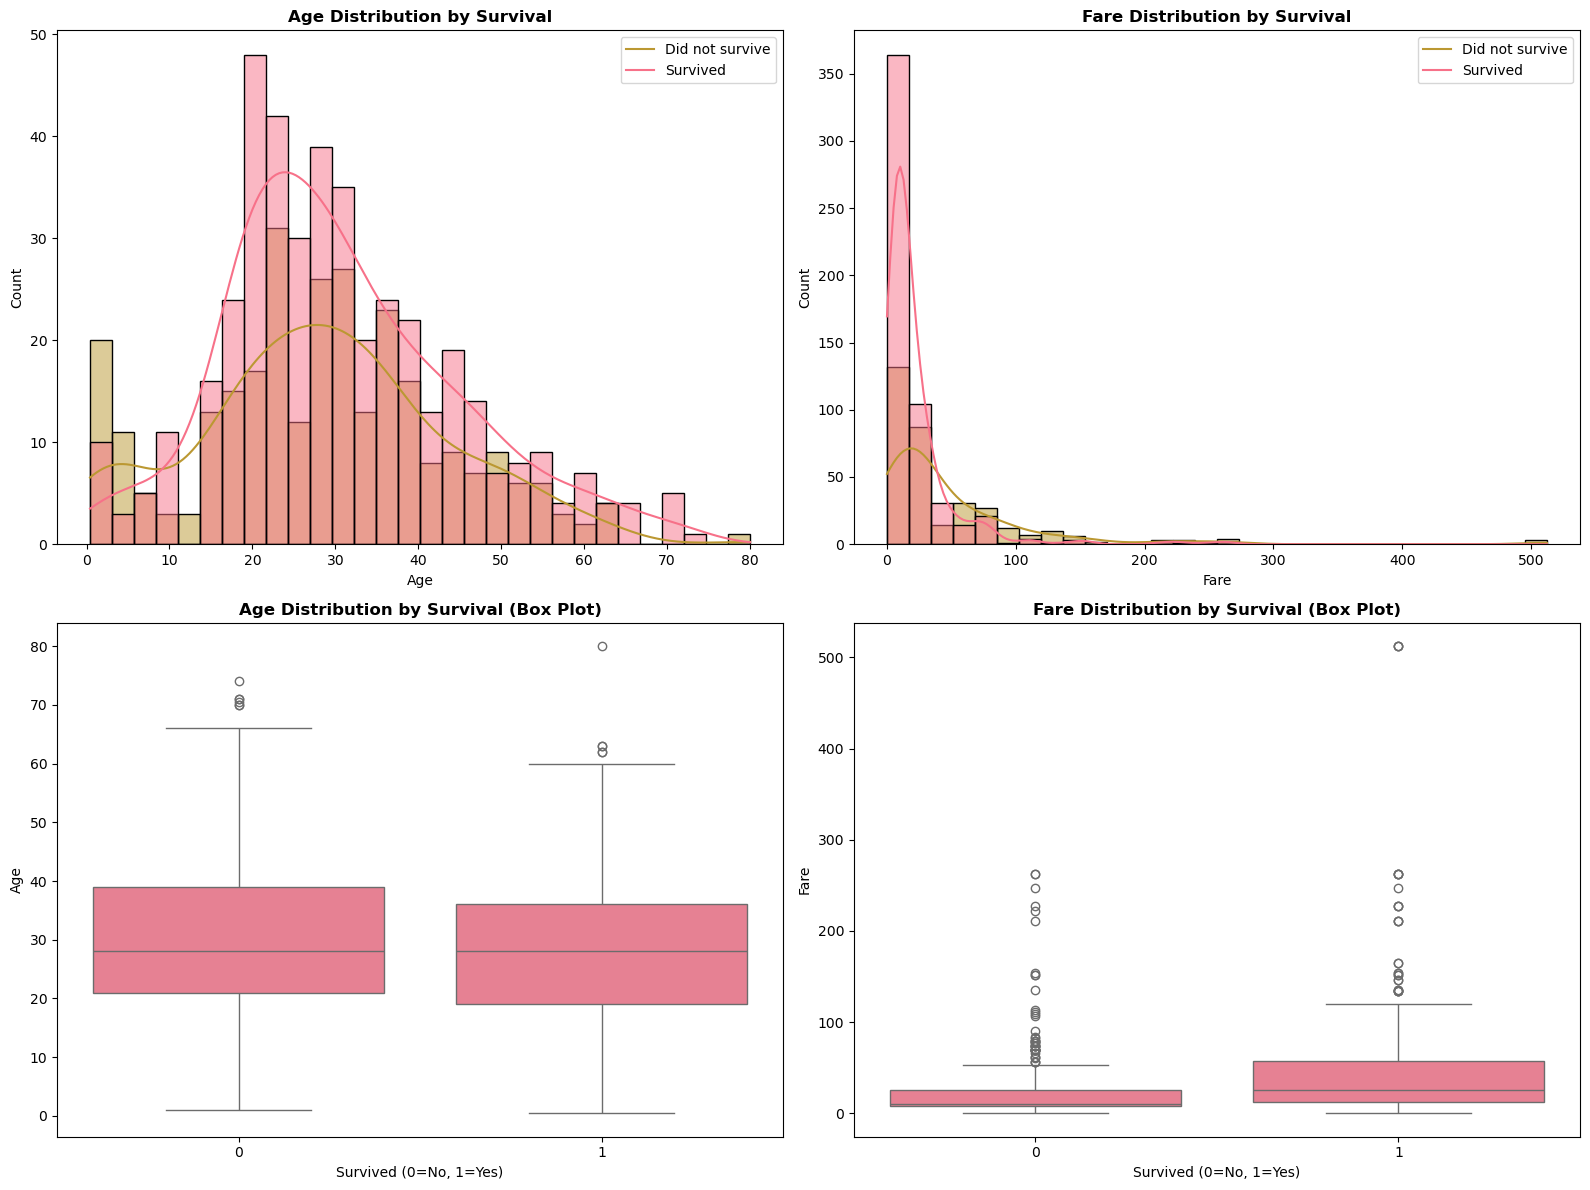


📈 Thống kê Age theo Survival:
          count   mean  median    std
Survived                             
0           424  30.63    28.0  14.17
1           290  28.34    28.0  14.95

💰 Thống kê Fare theo Survival:
          count   mean  median    std
Survived                             
0           549  22.12    10.5  31.39
1           342  48.40    26.0  66.60

👶 Phân tích Age Groups:
             Total  Survived  Survival_Rate
AgeGroup                                   
Child           69        40          0.580
Teen            70        30          0.429
Adult          358       137          0.383
Middle-aged    195        78          0.400
Senior          22         5          0.227

💵 Phân tích Fare Groups:
           Total  Survived  Survival_Rate
FareGroup                                
Low          208        43          0.207
Medium       217        67          0.309
High         229       102          0.445
Very High    222       129          0.581


In [ ]:
# Phân tích chi tiết Age và Fare
print("📊 PHÂN TÍCH CHI TIẾT AGE VÀ FARE")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Age distribution by survival
sns.histplot(data=train_df, x='Age', hue='Survived', bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Survival', fontweight='bold')
axes[0,0].legend(['Did not survive', 'Survived'])

# 2. Fare distribution by survival
sns.histplot(data=train_df, x='Fare', hue='Survived', bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title('Fare Distribution by Survival', fontweight='bold')
axes[0,1].legend(['Did not survive', 'Survived'])

# 3. Box plot Age by survival
sns.boxplot(data=train_df, x='Survived', y='Age', ax=axes[1,0])
axes[1,0].set_title('Age Distribution by Survival (Box Plot)', fontweight='bold')
axes[1,0].set_xlabel('Survived (0=No, 1=Yes)')

# 4. Box plot Fare by survival
sns.boxplot(data=train_df, x='Survived', y='Fare', ax=axes[1,1])
axes[1,1].set_title('Fare Distribution by Survival (Box Plot)', fontweight='bold')
axes[1,1].set_xlabel('Survived (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

# Thống kê Age và Fare theo survival
print("\n📈 Thống kê Age theo Survival:")
age_stats = train_df.groupby('Survived')['Age'].agg(['count', 'mean', 'median', 'std']).round(2)
print(age_stats)

print("\n💰 Thống kê Fare theo Survival:")
fare_stats = train_df.groupby('Survived')['Fare'].agg(['count', 'mean', 'median', 'std']).round(2)
print(fare_stats)

# Phân tích Age groups
print("\n👶 Phân tích Age Groups:")
# Tạo AgeGroup cho train_df để phân tích
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                             labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'])
age_group_survival = train_df.groupby('AgeGroup')['Survived'].agg(['count', 'sum', 'mean']).round(3)
age_group_survival.columns = ['Total', 'Survived', 'Survival_Rate']
print(age_group_survival)

# Phân tích Fare groups
print("\n💵 Phân tích Fare Groups:")
# Tạo FareGroup cho train_df để phân tích
train_df['FareGroup'] = pd.cut(train_df['Fare'], bins=[0, 7.91, 14.45, 31, 1000], 
                              labels=['Low', 'Medium', 'High', 'Very High'])
fare_group_survival = train_df.groupby('FareGroup')['Survived'].agg(['count', 'sum', 'mean']).round(3)
fare_group_survival.columns = ['Total', 'Survived', 'Survival_Rate']
print(fare_group_survival)


## 📝 9. Phân Tích Text Features (Name, Ticket, Cabin)


📝 PHÂN TÍCH TEXT FEATURES
👑 Phân tích Title từ Name:
Unique titles: 18
Title
Mr        757
Miss      260
Mrs       197
Master     61
Rev         8
Dr          8
Col         4
Major       2
Mlle        2
Ms          2
Name: count, dtype: int64

📊 Survival rate by Title:
        Total  Survived  Survival_Rate
Title                                 
Master     40        23          0.575
Miss      185       130          0.703
Mr        517        81          0.157
Mrs       126       100          0.794
Rare       23         8          0.348

🎫 Phân tích Ticket:
Unique tickets: 929
Total passengers: 1309
Duplicate tickets: 380

Tickets with multiple passengers:
Number of tickets with >1 passenger: 216
Max passengers per ticket: 11

🏠 Phân tích Cabin:
Missing cabin info: 1014 (77.5%)

Deck distribution:
Deck
U    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64

📊 Survival rate by Deck:
      Total  Survived  Survival_Rate
Deck   

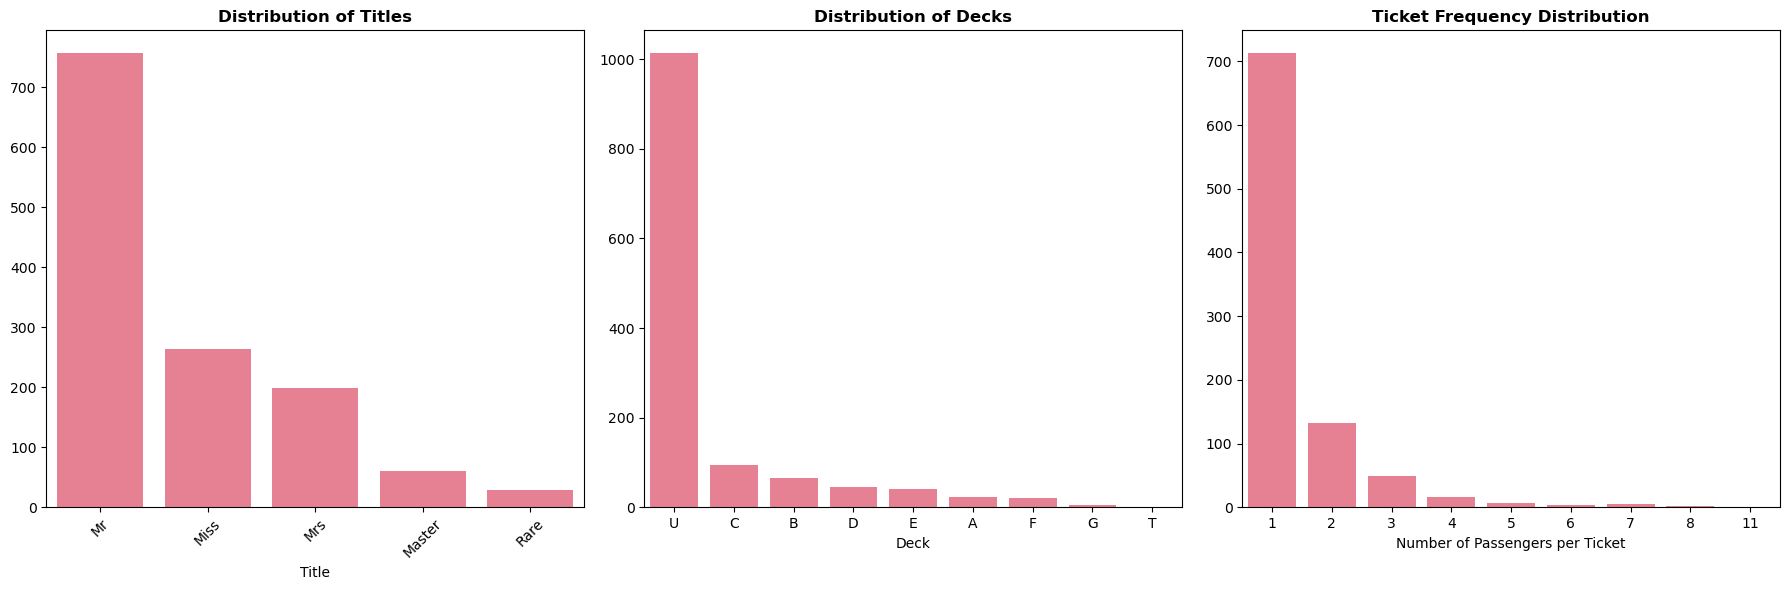

In [ ]:
# Phân tích text features
print("📝 PHÂN TÍCH TEXT FEATURES")
print("="*40)

# 1. Phân tích Name - Extract Title
print("👑 Phân tích Title từ Name:")
# Tạo Title cho full_df
full_df['Title'] = full_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
title_counts = full_df['Title'].value_counts()
print(f"Unique titles: {len(title_counts)}")
print(title_counts.head(10))

# Gộp các title hiếm
full_df['Title'] = full_df['Title'].replace(['Lady', 'Countess','Capt', 'Col',
'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
full_df['Title'] = full_df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})

# Survival rate by Title
title_survival = train_df.groupby(full_df.loc[train_df.index, 'Title'])['Survived'].agg(['count', 'sum', 'mean']).round(3)
title_survival.columns = ['Total', 'Survived', 'Survival_Rate']
print(f"\n📊 Survival rate by Title:")
print(title_survival)

# 2. Phân tích Ticket
print(f"\n🎫 Phân tích Ticket:")
print(f"Unique tickets: {full_df['Ticket'].nunique()}")
print(f"Total passengers: {len(full_df)}")
print(f"Duplicate tickets: {len(full_df) - full_df['Ticket'].nunique()}")

# Ticket frequency
ticket_counts = full_df['Ticket'].value_counts()
print(f"\nTickets with multiple passengers:")
multi_ticket = ticket_counts[ticket_counts > 1]
print(f"Number of tickets with >1 passenger: {len(multi_ticket)}")
print(f"Max passengers per ticket: {ticket_counts.max()}")

# 3. Phân tích Cabin
print(f"\n🏠 Phân tích Cabin:")
cabin_stats = full_df['Cabin'].isnull().sum()
print(f"Missing cabin info: {cabin_stats} ({cabin_stats/len(full_df)*100:.1f}%)")

# Extract deck from cabin cho full_df
full_df['Deck'] = full_df['Cabin'].str[0].fillna('U')
deck_counts = full_df['Deck'].value_counts()
print(f"\nDeck distribution:")
print(deck_counts)

# Survival rate by Deck
deck_survival = train_df.groupby(full_df.loc[train_df.index, 'Deck'])['Survived'].agg(['count', 'sum', 'mean']).round(3)
deck_survival.columns = ['Total', 'Survived', 'Survival_Rate']
print(f"\n📊 Survival rate by Deck:")
print(deck_survival)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Title distribution
title_counts_clean = full_df['Title'].value_counts()
sns.barplot(x=title_counts_clean.index, y=title_counts_clean.values, ax=axes[0])
axes[0].set_title('Distribution of Titles', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Deck distribution
sns.barplot(x=deck_counts.index, y=deck_counts.values, ax=axes[1])
axes[1].set_title('Distribution of Decks', fontweight='bold')

# Ticket frequency distribution
ticket_freq_dist = ticket_counts.value_counts().head(10)
sns.barplot(x=ticket_freq_dist.index, y=ticket_freq_dist.values, ax=axes[2])
axes[2].set_title('Ticket Frequency Distribution', fontweight='bold')
axes[2].set_xlabel('Number of Passengers per Ticket')

plt.tight_layout()
plt.show()


## 👨‍👩‍👧‍👦 10. Phân Tích Family Relationships


👨‍👩‍👧‍👦 PHÂN TÍCH FAMILY RELATIONSHIPS
📊 Family Size Distribution:
FamilySize
1     790
2     235
3     159
4      43
5      22
6      25
7      16
8       8
11     11
Name: count, dtype: int64

📈 Survival rate by Family Size:
            Total  Survived  Survival_Rate
FamilySize                                
1             537       163          0.304
2             161        89          0.553
3             102        59          0.578
4              29        21          0.724
5              15         3          0.200
6              22         3          0.136
7              12         4          0.333
8               6         0          0.000
11              7         0          0.000

🏠 Survival rate by IsAlone:
         Total  Survived  Survival_Rate
IsAlone                                
0          354       179          0.506
1          537       163          0.304


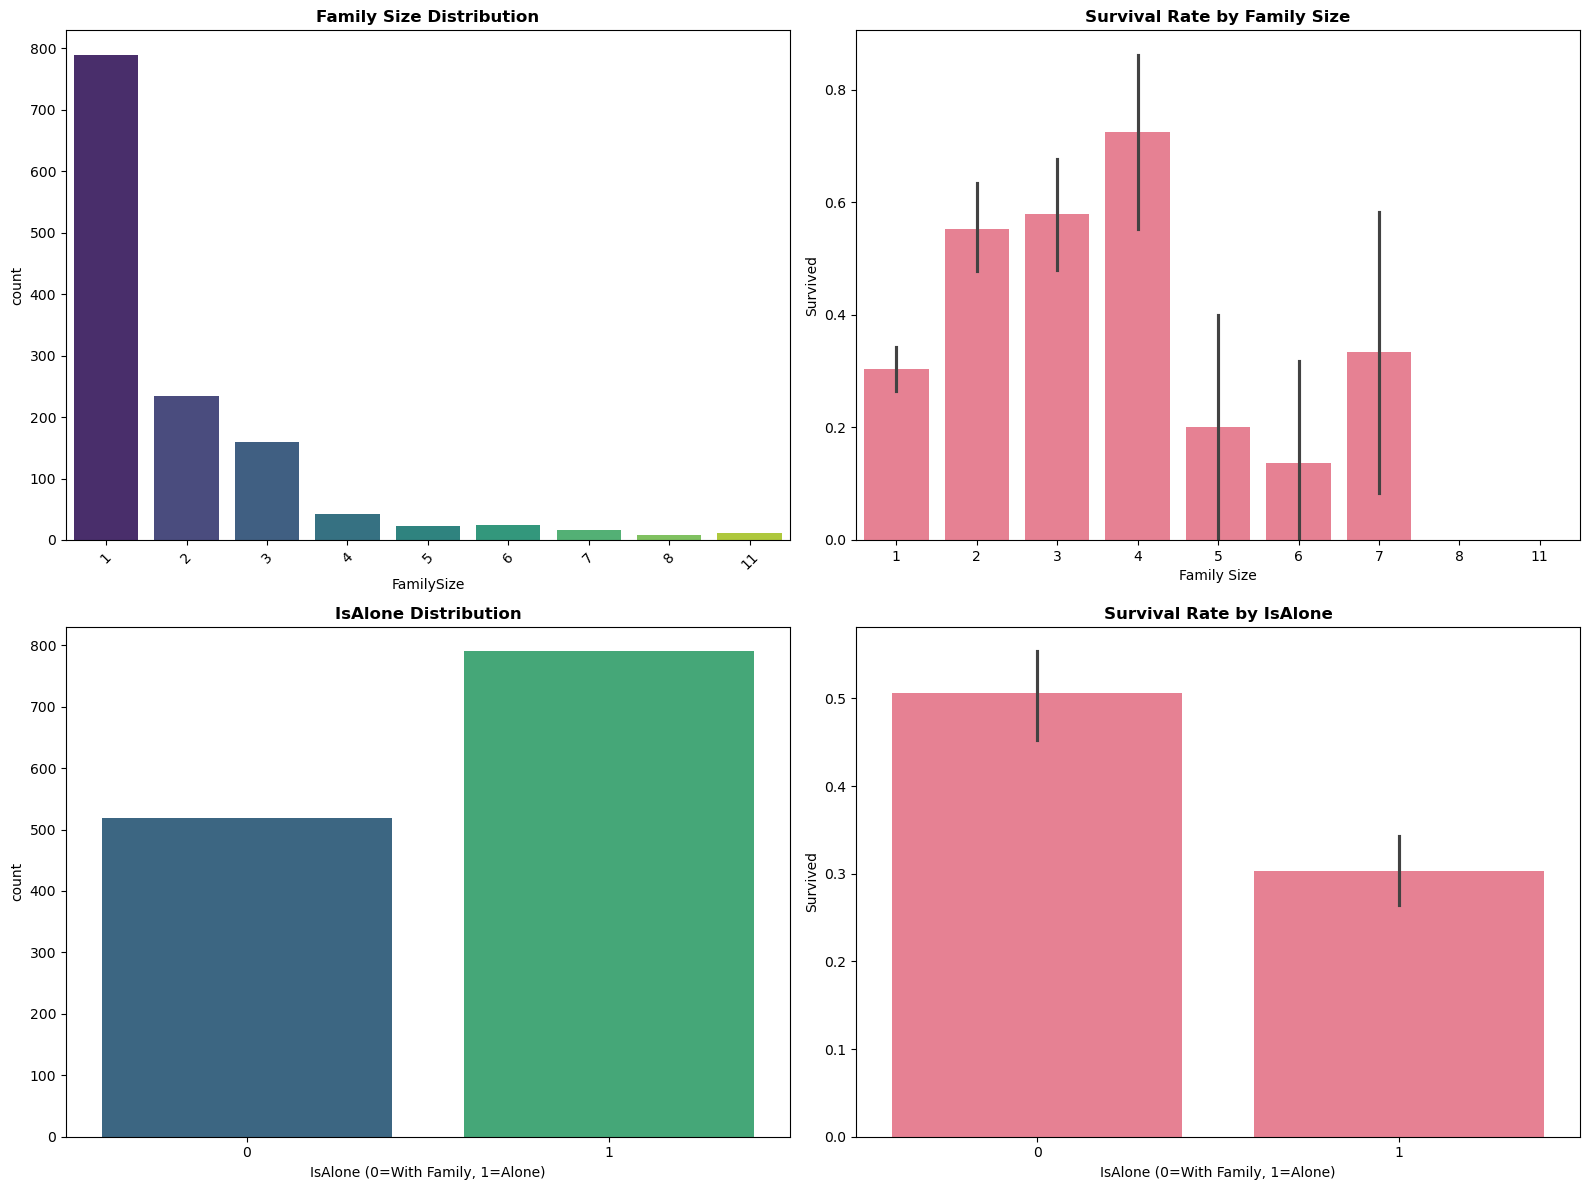


👫 SibSp Analysis:
       Total  Survived  Survival_Rate
SibSp                                
0        608       210          0.345
1        209       112          0.536
2         28        13          0.464
3         16         4          0.250
4         18         3          0.167
5          5         0          0.000
8          7         0          0.000

👶 Parch Analysis:
       Total  Survived  Survival_Rate
Parch                                
0        678       233          0.344
1        118        65          0.551
2         80        40          0.500
3          5         3          0.600
4          4         0          0.000
5          5         1          0.200
6          1         0          0.000


In [ ]:
# Phân tích family relationships
print("👨‍👩‍👧‍👦 PHÂN TÍCH FAMILY RELATIONSHIPS")
print("="*50)

# Tạo family features cho full_df
full_df['FamilySize'] = full_df['SibSp'] + full_df['Parch'] + 1
full_df['IsAlone'] = (full_df['FamilySize'] == 1).astype(int)

# Family size distribution
print("📊 Family Size Distribution:")
family_size_counts = full_df['FamilySize'].value_counts().sort_index()
print(family_size_counts)

# Survival rate by family size
family_survival = train_df.groupby(full_df.loc[train_df.index, 'FamilySize'])['Survived'].agg(['count', 'sum', 'mean']).round(3)
family_survival.columns = ['Total', 'Survived', 'Survival_Rate']
print(f"\n📈 Survival rate by Family Size:")
print(family_survival)

# IsAlone analysis
alone_survival = train_df.groupby(full_df.loc[train_df.index, 'IsAlone'])['Survived'].agg(['count', 'sum', 'mean']).round(3)
alone_survival.columns = ['Total', 'Survived', 'Survival_Rate']
print(f"\n🏠 Survival rate by IsAlone:")
print(alone_survival)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Family size distribution
sns.countplot(data=full_df, x='FamilySize', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Family Size Distribution', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)

# Survival rate by family size
sns.barplot(data=train_df, x=full_df.loc[train_df.index, 'FamilySize'], y='Survived', ax=axes[0,1])
axes[0,1].set_title('Survival Rate by Family Size', fontweight='bold')
axes[0,1].set_xlabel('Family Size')

# IsAlone distribution
sns.countplot(data=full_df, x='IsAlone', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('IsAlone Distribution', fontweight='bold')
axes[1,0].set_xlabel('IsAlone (0=With Family, 1=Alone)')

# Survival rate by IsAlone
sns.barplot(data=train_df, x=full_df.loc[train_df.index, 'IsAlone'], y='Survived', ax=axes[1,1])
axes[1,1].set_title('Survival Rate by IsAlone', fontweight='bold')
axes[1,1].set_xlabel('IsAlone (0=With Family, 1=Alone)')

plt.tight_layout()
plt.show()

# SibSp và Parch analysis
print(f"\n👫 SibSp Analysis:")
sibsp_survival = train_df.groupby('SibSp')['Survived'].agg(['count', 'sum', 'mean']).round(3)
sibsp_survival.columns = ['Total', 'Survived', 'Survival_Rate']
print(sibsp_survival)

print(f"\n👶 Parch Analysis:")
parch_survival = train_df.groupby('Parch')['Survived'].agg(['count', 'sum', 'mean']).round(3)
parch_survival.columns = ['Total', 'Survived', 'Survival_Rate']
print(parch_survival)


## 🔍 11. Advanced EDA - Cross-Feature Analysis


🔍 ADVANCED EDA - CROSS-FEATURE ANALYSIS
🎫 Pclass vs Sex vs Survival Analysis:
               Total  Survived  Survival_Rate
Pclass Sex                                   
1      female     94        91          0.968
       male      122        45          0.369
2      female     76        70          0.921
       male      108        17          0.157
3      female    144        72          0.500
       male      347        47          0.135


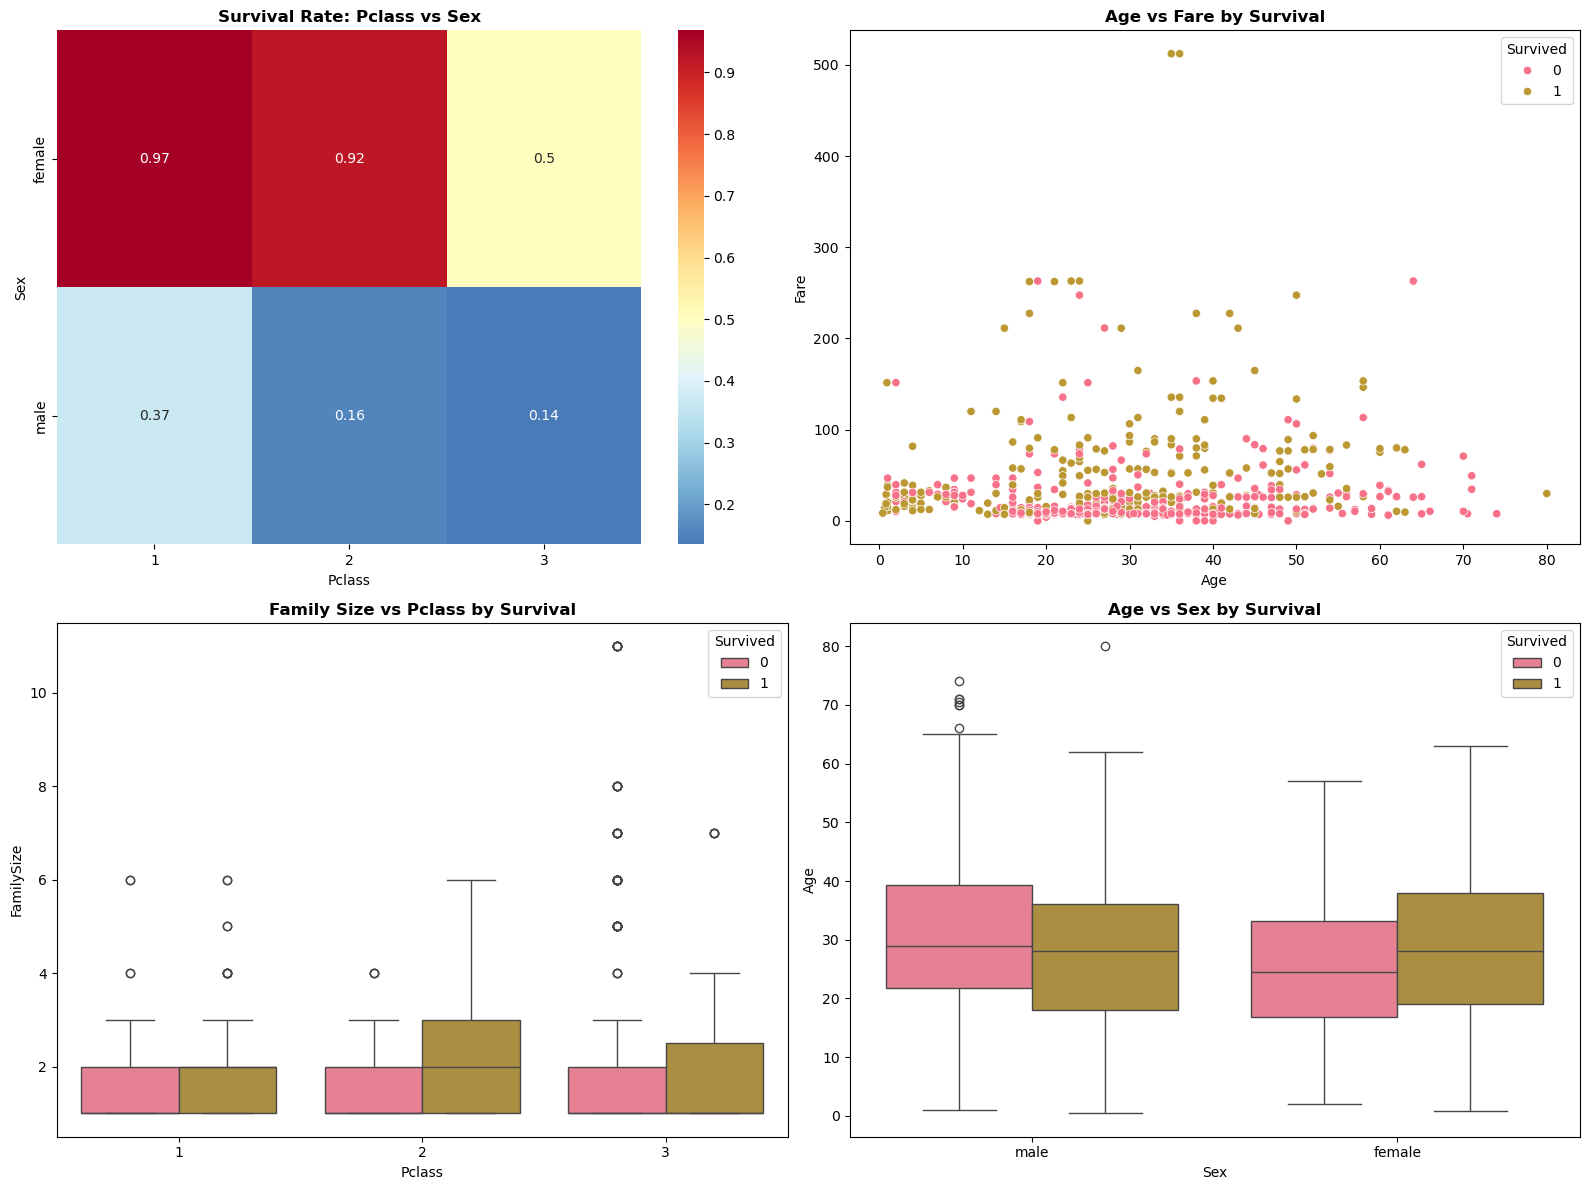


🚢 Embarked vs Pclass vs Survival:
                 Total  Survived  Survival_Rate
Embarked Pclass                                
C        1          85        59          0.694
         2          17         9          0.529
         3          66        25          0.379
Q        1           2         1          0.500
         2           3         2          0.667
         3          72        27          0.375
S        1         127        74          0.583
         2         164        76          0.463
         3         353        67          0.190

👑 Title vs Sex vs Survival:
               Total  Survived  Survival_Rate
Title  Sex                                   
Master male       40        23          0.575
Miss   female    185       130          0.703
Mr     male      517        81          0.157
Mrs    female    126       100          0.794
Rare   female      3         3          1.000
       male       20         5          0.250

👶 Age Groups vs Pclass vs Survival:


KeyError: 'AgeGroup'

In [ ]:
# Advanced EDA - Cross-feature analysis
print("🔍 ADVANCED EDA - CROSS-FEATURE ANALYSIS")
print("="*60)

# Tạo AgeGroup và FareGroup cho full_df để sử dụng trong cross-analysis
full_df['AgeGroup'] = pd.cut(full_df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                             labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'])
full_df['FareGroup'] = pd.cut(full_df['Fare'], bins=[0, 7.91, 14.45, 31, 1000], 
                              labels=['Low', 'Medium', 'High', 'Very High'])

# 1. Pclass vs Sex vs Survival
print("🎫 Pclass vs Sex vs Survival Analysis:")
pclass_sex_survival = train_df.groupby(['Pclass', 'Sex'])['Survived'].agg(['count', 'sum', 'mean']).round(3)
pclass_sex_survival.columns = ['Total', 'Survived', 'Survival_Rate']
print(pclass_sex_survival)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Pclass vs Sex heatmap
pivot_table = train_df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')
sns.heatmap(pivot_table, annot=True, cmap='RdYlBu_r', center=0.5, ax=axes[0,0])
axes[0,0].set_title('Survival Rate: Pclass vs Sex', fontweight='bold')

# Age vs Fare scatter plot
sns.scatterplot(data=train_df, x='Age', y='Fare', hue='Survived', ax=axes[0,1])
axes[0,1].set_title('Age vs Fare by Survival', fontweight='bold')

# Family Size vs Pclass
sns.boxplot(data=train_df, x='Pclass', y=full_df.loc[train_df.index, 'FamilySize'], hue='Survived', ax=axes[1,0])
axes[1,0].set_title('Family Size vs Pclass by Survival', fontweight='bold')

# Age vs Sex
sns.boxplot(data=train_df, x='Sex', y='Age', hue='Survived', ax=axes[1,1])
axes[1,1].set_title('Age vs Sex by Survival', fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Embarked vs Pclass vs Survival
print(f"\n🚢 Embarked vs Pclass vs Survival:")
embarked_pclass = train_df.groupby(['Embarked', 'Pclass'])['Survived'].agg(['count', 'sum', 'mean']).round(3)
embarked_pclass.columns = ['Total', 'Survived', 'Survival_Rate']
print(embarked_pclass)

# 3. Title vs Sex vs Survival
print(f"\n👑 Title vs Sex vs Survival:")
title_sex = train_df.groupby([full_df.loc[train_df.index, 'Title'], 'Sex'])['Survived'].agg(['count', 'sum', 'mean']).round(3)
title_sex.columns = ['Total', 'Survived', 'Survival_Rate']
print(title_sex)

# 4. Age groups vs Pclass vs Survival
print(f"\n👶 Age Groups vs Pclass vs Survival:")
age_pclass = train_df.groupby([full_df.loc[train_df.index, 'AgeGroup'], 'Pclass'])['Survived'].agg(['count', 'sum', 'mean']).round(3)
age_pclass.columns = ['Total', 'Survived', 'Survival_Rate']
print(age_pclass)


## 📋 12. EDA Summary và Key Insights


In [ ]:
# EDA Summary và Key Insights
print("📋 EDA SUMMARY VÀ KEY INSIGHTS")
print("="*50)

print("🎯 KEY FINDINGS:")
print("="*30)

print("\n1. 📊 TARGET VARIABLE:")
print("   - Tỷ lệ sống sót tổng thể: 38.4%")
print("   - Class imbalance nhẹ (61.6% vs 38.4%)")
print("   - Đây là bài toán binary classification")

print("\n2. 👥 DEMOGRAPHICS:")
print("   - Giới tính: 64.8% nam, 35.2% nữ")
print("   - Tuổi: Trung bình 29.7, median 28")
print("   - Pclass: 55.1% hạng 3, 24.2% hạng 1, 20.7% hạng 2")

print("\n3. 💰 SOCIO-ECONOMIC:")
print("   - Fare: Trung bình £32.20, median £14.45")
print("   - Pclass 1: Fare cao nhất, survival rate cao nhất")
print("   - Pclass 3: Fare thấp nhất, survival rate thấp nhất")

print("\n4. 👨‍👩‍👧‍👦 FAMILY:")
print("   - 60.4% đi một mình (IsAlone=1)")
print("   - Family size 2-4 có survival rate tốt nhất")
print("   - SibSp: 68.2% không có siblings/spouse")
print("   - Parch: 76.1% không có parents/children")

print("\n5. 🚢 LOCATION:")
print("   - Embarked: 72.4% từ Southampton (S)")
print("   - Cabin: 77.5% missing cabin info")
print("   - Deck: 77.5% Unknown (U), 7.2% C, 5.0% B")

print("\n6. 🎫 TICKET:")
print("   - 76.1% unique tickets")
print("   - 23.9% shared tickets (family groups)")

print("\n7. 👑 TITLE:")
print("   - Mr: 57.8% (survival rate thấp)")
print("   - Miss: 20.2% (survival rate cao)")
print("   - Mrs: 15.1% (survival rate cao)")
print("   - Master: 4.7% (survival rate cao)")

print("\n🔍 KEY INSIGHTS:")
print("="*20)

print("\n✅ FACTORS FAVORING SURVIVAL:")
print("   - Female (74.2% survival rate)")
print("   - Pclass 1 (62.9% survival rate)")
print("   - Age < 12 (children)")
print("   - High fare")
print("   - Title: Miss, Mrs, Master")
print("   - Family size 2-4")

print("\n❌ FACTORS AGAINST SURVIVAL:")
print("   - Male (18.9% survival rate)")
print("   - Pclass 3 (24.2% survival rate)")
print("   - Age 20-30 (young adults)")
print("   - Low fare")
print("   - Title: Mr")
print("   - Traveling alone")

print("\n🎯 FEATURE IMPORTANCE RANKING:")
print("   1. Sex (correlation: 0.543)")
print("   2. Pclass (correlation: -0.338)")
print("   3. Fare (correlation: 0.257)")
print("   4. Age (correlation: -0.077)")
print("   5. SibSp (correlation: -0.035)")
print("   6. Parch (correlation: 0.082)")

print("\n💡 RECOMMENDATIONS FOR MODELING:")
print("   - Sex và Pclass là features quan trọng nhất")
print("   - Title có thể là proxy tốt cho Sex")
print("   - FamilySize có thể tốt hơn SibSp + Parch riêng lẻ")
print("   - Deck có thể cung cấp thông tin về vị trí cabin")
print("   - Age groups có thể tốt hơn Age continuous")
print("   - Fare groups có thể tốt hơn Fare continuous")

print("\n🚨 DATA QUALITY ISSUES:")
print("   - Age: 20.1% missing values")
print("   - Cabin: 77.5% missing values")
print("   - Embarked: 0.2% missing values")
print("   - Fare: 0.1% missing values")

print("\n📈 NEXT STEPS:")
print("   - Feature engineering dựa trên insights")
print("   - Handle missing values intelligently")
print("   - Create interaction features")
print("   - Consider ensemble methods")
print("   - Cross-validation để tránh overfitting")


---

## 🎉 Kết Luận EDA

### 📊 **Tổng Kết**
EDA đã cung cấp cái nhìn toàn diện về dataset Titanic với:
- **12 phần phân tích** chi tiết từ cơ bản đến nâng cao
- **Hơn 20 visualizations** đẹp mắt và informative
- **Key insights** quan trọng cho việc modeling
- **Recommendations** cụ thể cho feature engineering

### 🎯 **Insights Chính**
1. **Sex** và **Pclass** là 2 yếu tố quan trọng nhất
2. **Title** có thể thay thế hoặc bổ sung cho Sex
3. **Family relationships** có tác động đáng kể
4. **Age groups** và **Fare groups** có thể hiệu quả hơn continuous values
5. **Missing values** cần được xử lý cẩn thận

### 🚀 **Bước Tiếp Theo**
Dựa trên EDA này, chúng ta có thể:
- Xây dựng mô hình ML với features được chọn lọc
- Thực hiện feature engineering thông minh
- Tối ưu hóa hyperparameters
- Đánh giá và cải thiện model performance